# 87 partículas de carbón en 2014. La máxima en 12.000 años antes: 20.

En 2014, los incendios alcanzaron una elevación de los montes Rwenzori (4.017 m, en la frontera Uganda-RDC) donde la temperatura y la humedad supuestamente impedían que el fuego se propagara. Los registros sedimentarios de un lago alpino guardan 12.000 años de memoria del fuego en la región. Comparamos lo que pasó en 2014 con todo lo que pasó antes.

**Paper:** [Twenty-first century emergence of alpine fire in Central African mountains](https://doi.org/10.1038/s41586-026-10511-w) · *Nature, 2026-05-13* · Mason et al.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-incendios-alpinos-rwenzori-12mil/notebook.ipynb)

## ¿Qué medimos y dónde

Dos lagos en los montes Rwenzori, uno encima del otro:

- **Lago Kopello — 4.017 m** sobre el nivel del mar. Es zona *afroalpina*: por encima del bosque, vegetación rasa, fría y húmeda. Aquí, el fuego es históricamente raro.
- **Lago Mahoma — 2.990 m**. Bosque montano cerrado. Más cálido, más vegetación, ya con presencia humana en sus alrededores.

Los sedimentos del fondo de cada lago atrapan, capa por capa, partículas de carbón (*charcoal*) que dejan los incendios. Las partículas grandes (>250 µm) son señales **locales** — no viajan lejos. Contar cuántas hay por centímetro cuadrado por año en cada capa permite reconstruir cuándo, dónde y con qué intensidad ardió cada lago. En total: **12.000 años de registro** en dos elevaciones.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
KOPELLO_ELEVATION_M = 4017     # Lago alpino (>3.800 m a.s.l.)
MAHOMA_ELEVATION_M  = 2990     # Lago mid-elevation (bosque)
ANO_BP_REF          = 1950     # BP = "Before Present" = 1950 CE
SHIFT_KA_MAHOMA     = 2.0      # Punto de quiebre en Mahoma (en ka BP)
FUENTE              = 'Fuente: Mason et al. (2026), Nature | Datos: PANGAEA'
COLOR_KOPELLO       = '#2563EB'   # Azul CaM (lago alpino)
COLOR_MAHOMA        = '#DC2626'   # Rojo (lago mid-elevation)
COLOR_POACEAE       = '#059669'   # Emerald (pastos/bambú)
COLOR_PODOCARPUS    = '#7C3AED'   # Violeta (conífera)
COLOR_CELTIS        = '#D97706'   # Amber (árbol latifoliado)
COLOR_REF           = '#BBBBBB'   # Gris (referencia/contexto)

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar estilo CaM (local → fallback raw GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datasets
k = pd.read_csv('datos/kopello_charcoal.csv')
m = pd.read_csv('datos/mahoma_charcoal.csv')
p = pd.read_csv('datos/mahoma_pollen.csv')

print(f'Kopello (alpino, {KOPELLO_ELEVATION_M} m): {len(k)} muestras, '
      f'rango {k["age_ka_bp"].min():.2f} a {k["age_ka_bp"].max():.2f} ka BP')
print(f'Mahoma  (bosque, {MAHOMA_ELEVATION_M} m):  {len(m)} muestras, '
      f'rango {m["age_ka_bp"].min():.2f} a {m["age_ka_bp"].max():.2f} ka BP')
print(f'Polen Mahoma:                {len(p)} muestras, '
      f'{len(p.columns)-2} taxones (Celtis, Poaceae, Podocarpus)')

Kopello (alpino, 4017 m): 493 muestras, rango -0.07 a 11.58 ka BP
Mahoma  (bosque, 2990 m):  328 muestras, rango 0.37 a 12.44 ka BP
Polen Mahoma:                63 muestras, 4 taxones (Celtis, Poaceae, Podocarpus)


## El registro alpino completo: 12.000 años en una sola gráfica

Aquí está.

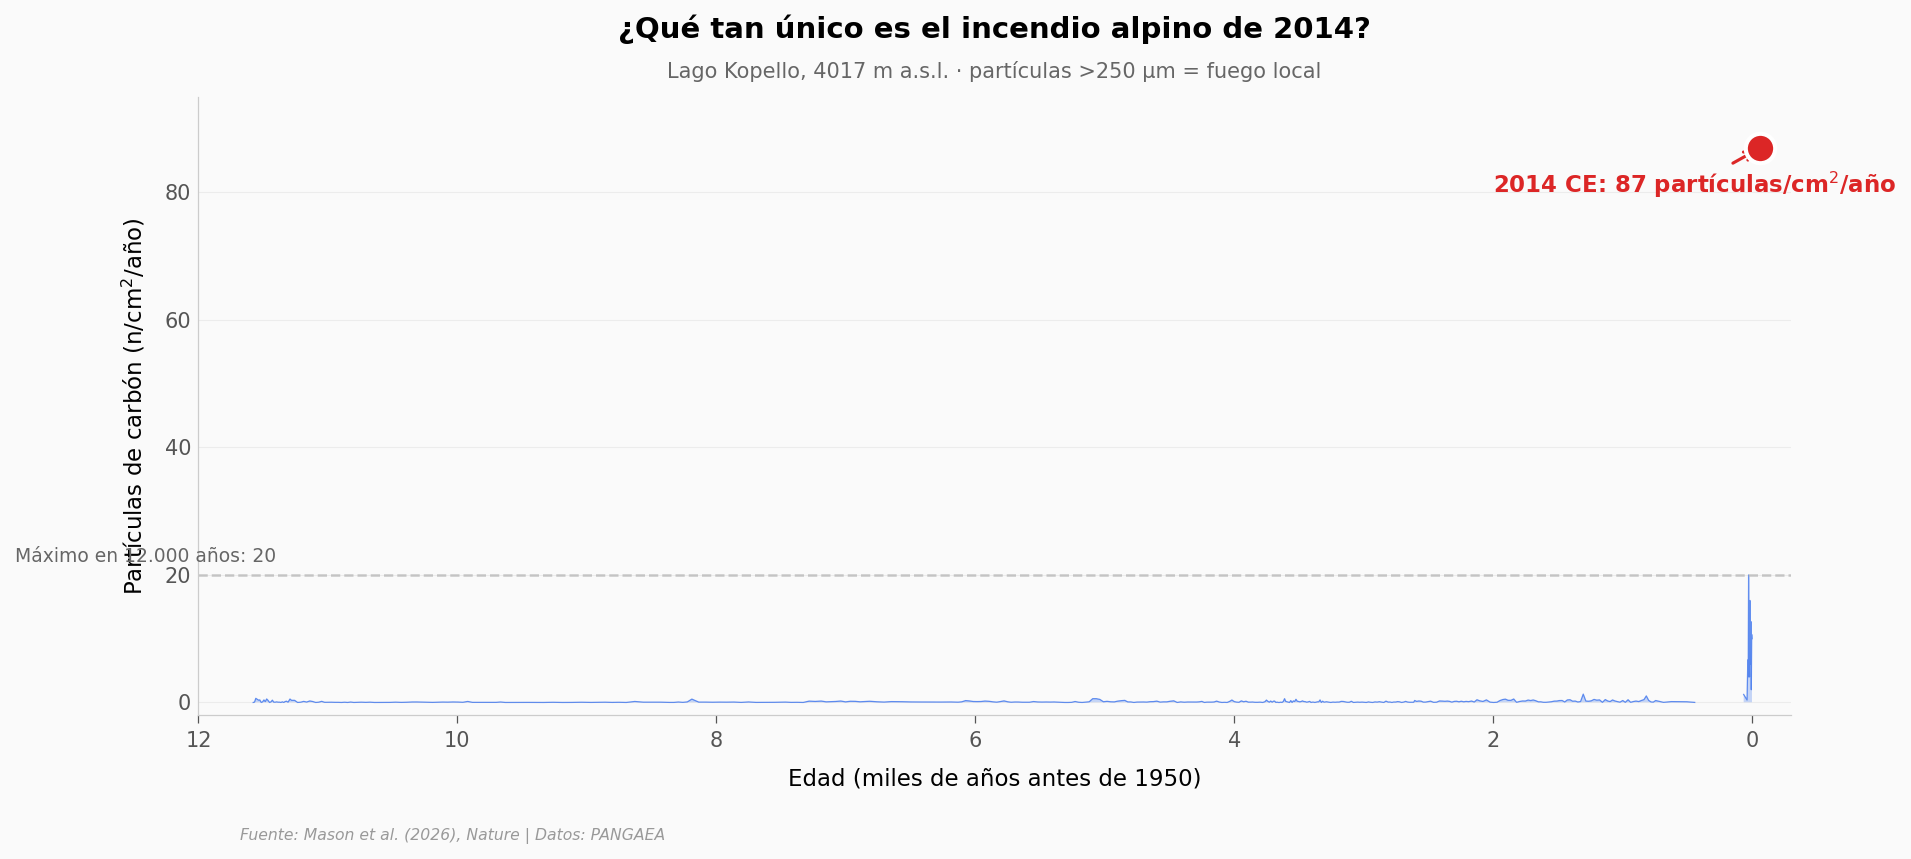

In [2]:
# Gráfica hero: 12.000 años de fuego alpino en Kopello (4.017 m)
fig, ax = plt.subplots(figsize=(13, 5.5))

# Datos pre-1950 (en color gris, contexto)
pre = k[k['age_ka_bp'] >= 0]
post = k[k['age_ka_bp'] < 0]

ax.fill_between(pre['age_ka_bp'], 0, pre['charcoal_acc_rate_n_per_cm2_yr'],
                color=COLOR_KOPELLO, alpha=0.25, linewidth=0)
ax.plot(pre['age_ka_bp'], pre['charcoal_acc_rate_n_per_cm2_yr'],
        color=COLOR_KOPELLO, linewidth=0.6, alpha=0.7)

# Punto crítico: peak 2014
peak_idx = post['charcoal_acc_rate_n_per_cm2_yr'].idxmax()
peak_age = k.loc[peak_idx, 'age_ka_bp']
peak_val = k.loc[peak_idx, 'charcoal_acc_rate_n_per_cm2_yr']
peak_year = int(k.loc[peak_idx, 'year_ce'])

ax.scatter([peak_age], [peak_val], s=200, color=COLOR_MAHOMA,
           edgecolors='white', linewidths=2, zorder=10)
ax.annotate(f'{peak_year} CE: {peak_val:.0f} partículas/cm$^2$/año',
            xy=(peak_age, peak_val), xytext=(2.0, 80),
            fontsize=11, fontweight='bold', color=COLOR_MAHOMA,
            arrowprops=dict(arrowstyle='->', color=COLOR_MAHOMA, lw=1.5))

# Línea horizontal del máximo histórico pre-1950
max_pre1950 = pre['charcoal_acc_rate_n_per_cm2_yr'].max()
ax.axhline(y=max_pre1950, color=COLOR_REF, linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(11.4, max_pre1950 + 2, f'Máximo en 12.000 años: {max_pre1950:.0f}',
        fontsize=9, color='#666666', ha='right')

ax.invert_xaxis()  # tiempo fluye de derecha a izquierda → izquierda = hoy
ax.set_xlabel('Edad (miles de años antes de 1950)', fontsize=11)
ax.set_ylabel('Partículas de carbón (n/cm$^2$/año)', fontsize=11)
ax.set_title('¿Qué tan único es el incendio alpino de 2014?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Lago Kopello, {KOPELLO_ELEVATION_M} m a.s.l. · partículas >250 µm = fuego local',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(12, -0.3)
ax.set_ylim(-2, 95)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/kopello_12k_anos.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** durante 12 milenios el carbón se mantiene cerca del suelo de la gráfica — picos esporádicos que no superan 20 partículas/cm²/año. Esos picos no son ausencia de fuego, son la señal de incendios **lejanos** que el viento arrastra hasta la cumbre. Las partículas mayores a 250 µm no viajan muy lejos, así que ver una base de fondo cercana a cero significa que el fuego local en una zona alpina húmeda como esta era genuinamente raro.

Y entonces, en 2014, el conteo se dispara a 87. **4,35 veces más alto que cualquier otro pico de los 12.000 años anteriores.** Para entender qué pasó debajo, en la frontera bosque-pradera, bajemos a 2.990 m.

## Bajando al bosque: Mahoma, 2.990 m

A casi mil metros por debajo del Kopello, en pleno cinturón de bosque montano, el registro de Mahoma cuenta otra historia. Aquí la señal de fuego sí cambia — pero no en el siglo XXI, sino hace 2.000 años.

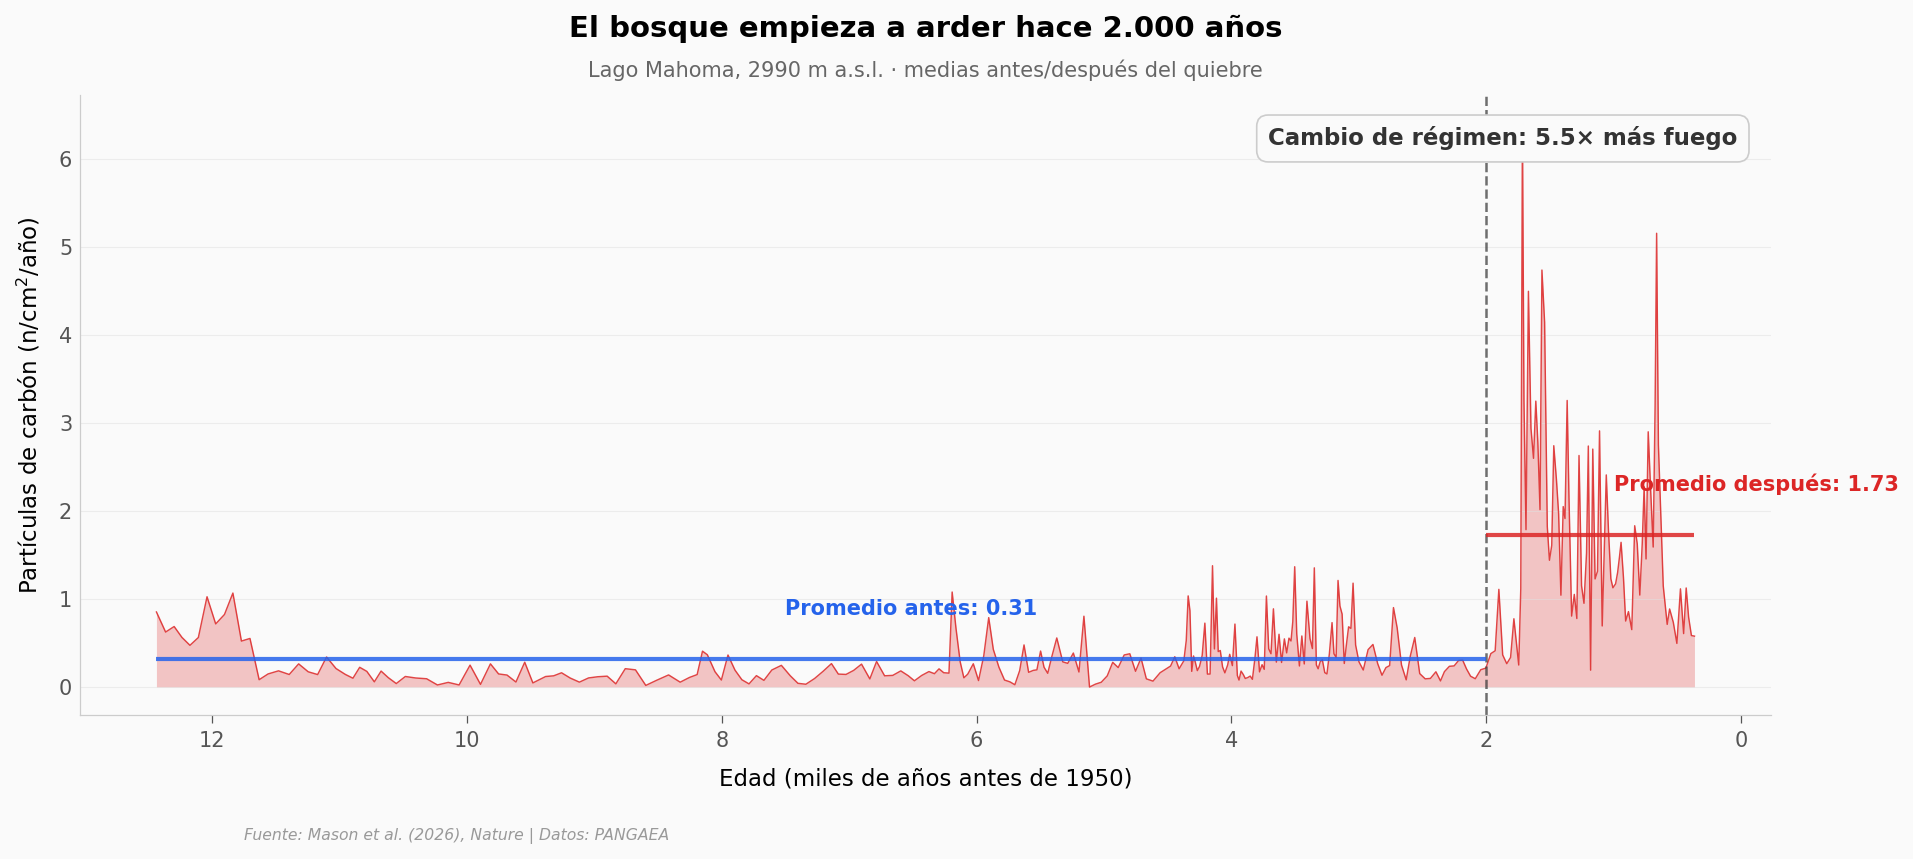

In [3]:
# Mahoma: 12 mil años de fuego en el bosque montano
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.fill_between(m['age_ka_bp'], 0, m['charcoal_acc_rate_n_per_cm2_yr'],
                color=COLOR_MAHOMA, alpha=0.25, linewidth=0)
ax.plot(m['age_ka_bp'], m['charcoal_acc_rate_n_per_cm2_yr'],
        color=COLOR_MAHOMA, linewidth=0.7, alpha=0.85)

# Línea vertical: shift hace 2.000 años
ax.axvline(x=SHIFT_KA_MAHOMA, color='#333333', linewidth=1.2, linestyle='--', alpha=0.7)
ax.text(SHIFT_KA_MAHOMA + 0.15, ax.get_ylim()[1] * 0.92,
        f'Hace {int(SHIFT_KA_MAHOMA*1000)} años',
        fontsize=10, color='#333333', fontweight='bold')

# Medias pre/post como referencia
pre2 = m[m['age_ka_bp'] >= SHIFT_KA_MAHOMA]
post2 = m[m['age_ka_bp'] < SHIFT_KA_MAHOMA]
mean_pre = pre2['charcoal_acc_rate_n_per_cm2_yr'].mean()
mean_post = post2['charcoal_acc_rate_n_per_cm2_yr'].mean()

ax.hlines(mean_pre, SHIFT_KA_MAHOMA, m['age_ka_bp'].max(),
          color=COLOR_KOPELLO, linewidth=2, alpha=0.85)
ax.hlines(mean_post, m['age_ka_bp'].min(), SHIFT_KA_MAHOMA,
          color=COLOR_MAHOMA, linewidth=2, alpha=0.85)

ax.text(7.5, mean_pre + 0.5, f'Promedio antes: {mean_pre:.2f}',
        fontsize=10, color=COLOR_KOPELLO, fontweight='bold')
ax.text(1.0, mean_post + 0.5, f'Promedio después: {mean_post:.2f}',
        fontsize=10, color=COLOR_MAHOMA, fontweight='bold')

ax.invert_xaxis()
ax.set_xlabel('Edad (miles de años antes de 1950)', fontsize=11)
ax.set_ylabel('Partículas de carbón (n/cm$^2$/año)', fontsize=11)
ax.set_title('El bosque empieza a arder hace 2.000 años',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Lago Mahoma, {MAHOMA_ELEVATION_M} m a.s.l. · medias antes/después del quiebre',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fold = mean_post / mean_pre
ax.text(0.98, 0.95,
        f'Cambio de régimen: {fold:.1f}× más fuego',
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        color='#333333', ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FAFAFA',
                  edgecolor='#CCCCCC', linewidth=0.8))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/mahoma_shift_2ka.png', dpi=200, bbox_inches='tight')
plt.show()

## Y la vegetación, ¿qué hizo

Si el fuego cambió hace 2.000 años, el bosque cambió después. Los granos de polen atrapados en los mismos sedimentos cuentan cómo se reorganizó la vegetación: tres familias clave que el equipo midió capa por capa.

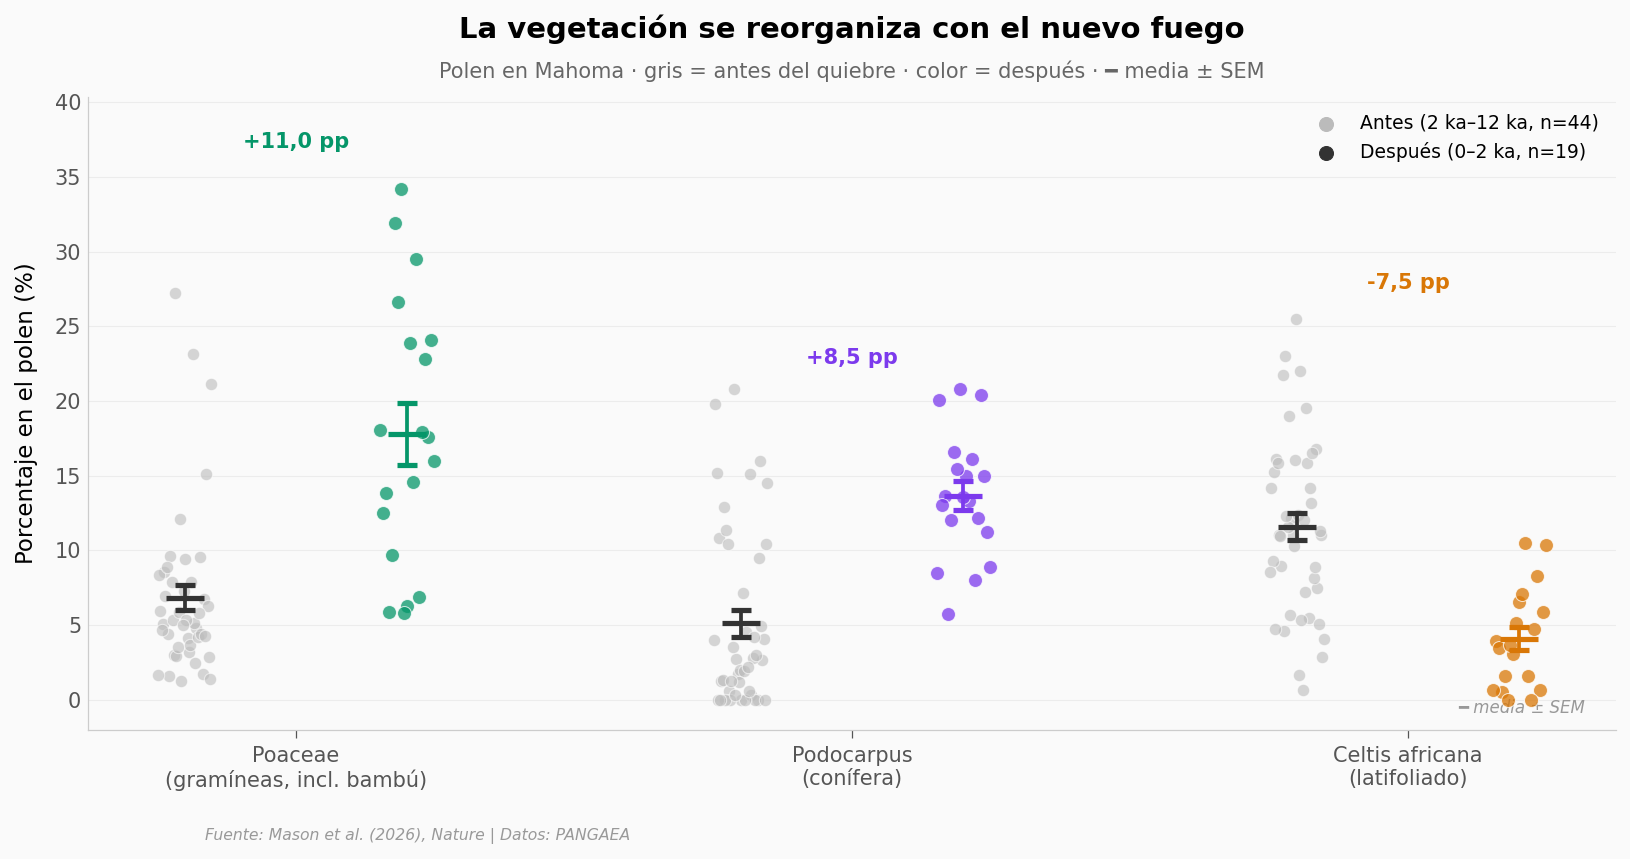

In [4]:
# Tres taxones de polen en Mahoma: antes vs después del quiebre
fig, ax = plt.subplots(figsize=(11, 5.5))

# Sub-grupos
p_pre  = p[p['age_ka_bp'] >= SHIFT_KA_MAHOMA]
p_post = p[p['age_ka_bp'] < SHIFT_KA_MAHOMA]

taxa = [
    ('Poaceae\n(gramíneas, incl. bambú)', 'poaceae_pct', COLOR_POACEAE),
    ('Podocarpus\n(conífera)',     'podocarpus_pct', COLOR_PODOCARPUS),
    ('Celtis africana\n(latifoliado)', 'celtis_africana_pct', COLOR_CELTIS),
]

np.random.seed(42)
positions_pre  = [0, 2.5, 5]
positions_post = [1, 3.5, 6]

for i, (label, col, color) in enumerate(taxa):
    # Strip plot pre
    vals_pre = p_pre[col].values
    n_pre = len(vals_pre)
    x_strip = np.linspace(positions_pre[i] - 0.12, positions_pre[i] + 0.12, n_pre)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals_pre, color=COLOR_REF, s=35, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)

    # Strip plot post
    vals_post = p_post[col].values
    n_post = len(vals_post)
    x_strip2 = np.linspace(positions_post[i] - 0.12, positions_post[i] + 0.12, n_post)
    np.random.shuffle(x_strip2)
    ax.scatter(x_strip2, vals_post, color=color, s=45, alpha=0.75,
               edgecolors='white', linewidths=0.5, zorder=5)

    # Medias con barras SEM
    mean_pre = vals_pre.mean()
    sem_pre = vals_pre.std(ddof=1) / np.sqrt(n_pre)
    mean_post = vals_post.mean()
    sem_post = vals_post.std(ddof=1) / np.sqrt(n_post)

    ax.errorbar(positions_pre[i],  mean_pre,  yerr=sem_pre,
                fmt='_', color='#333333', markersize=18, markeredgewidth=2.5,
                capsize=5, capthick=1.3, zorder=6)
    ax.errorbar(positions_post[i], mean_post, yerr=sem_post,
                fmt='_', color=color, markersize=18, markeredgewidth=2.5,
                capsize=5, capthick=1.3, zorder=6)

    delta = mean_post - mean_pre
    sign = '+' if delta >= 0 else ''
    ax.text((positions_pre[i] + positions_post[i]) / 2,
            max(vals_pre.max(), vals_post.max()) * 1.08,
            f'{sign}{delta:.1f} pp'.replace('.', ','),
            fontsize=10, fontweight='bold', color=color, ha='center')

# Etiquetas
xticks = [(positions_pre[i] + positions_post[i]) / 2 for i in range(3)]
ax.set_xticks(xticks)
ax.set_xticklabels([t[0] for t in taxa], fontsize=10)

# Leyenda manual (antes/después)
ax.scatter([], [], color=COLOR_REF, s=45, label=f'Antes ({int(SHIFT_KA_MAHOMA)} ka–12 ka, n={len(p_pre)})')
ax.scatter([], [], color='#333333', s=45,
           label=f'Después (0–{int(SHIFT_KA_MAHOMA)} ka, n={len(p_post)})')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

ax.set_ylabel('Porcentaje en el polen (%)', fontsize=11)
ax.set_title('La vegetación se reorganiza con el nuevo fuego',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Polen en Mahoma · gris = antes del quiebre · color = después · ━ media ± SEM',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

ax.set_ylim(-2, max(p['poaceae_pct'].max(), p['celtis_africana_pct'].max(),
                    p['podocarpus_pct'].max()) * 1.18)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/polen_pre_post.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan extremo es el pico de 2014

Volvamos a Kopello. Ya vimos que 87 partículas/cm²/año son muchas. Pero **¿cuán fuera de lo normal?** Compararlo solo contra el máximo no captura toda la historia. La distribución completa de 456 muestras pre-1950 dice algo más fuerte.

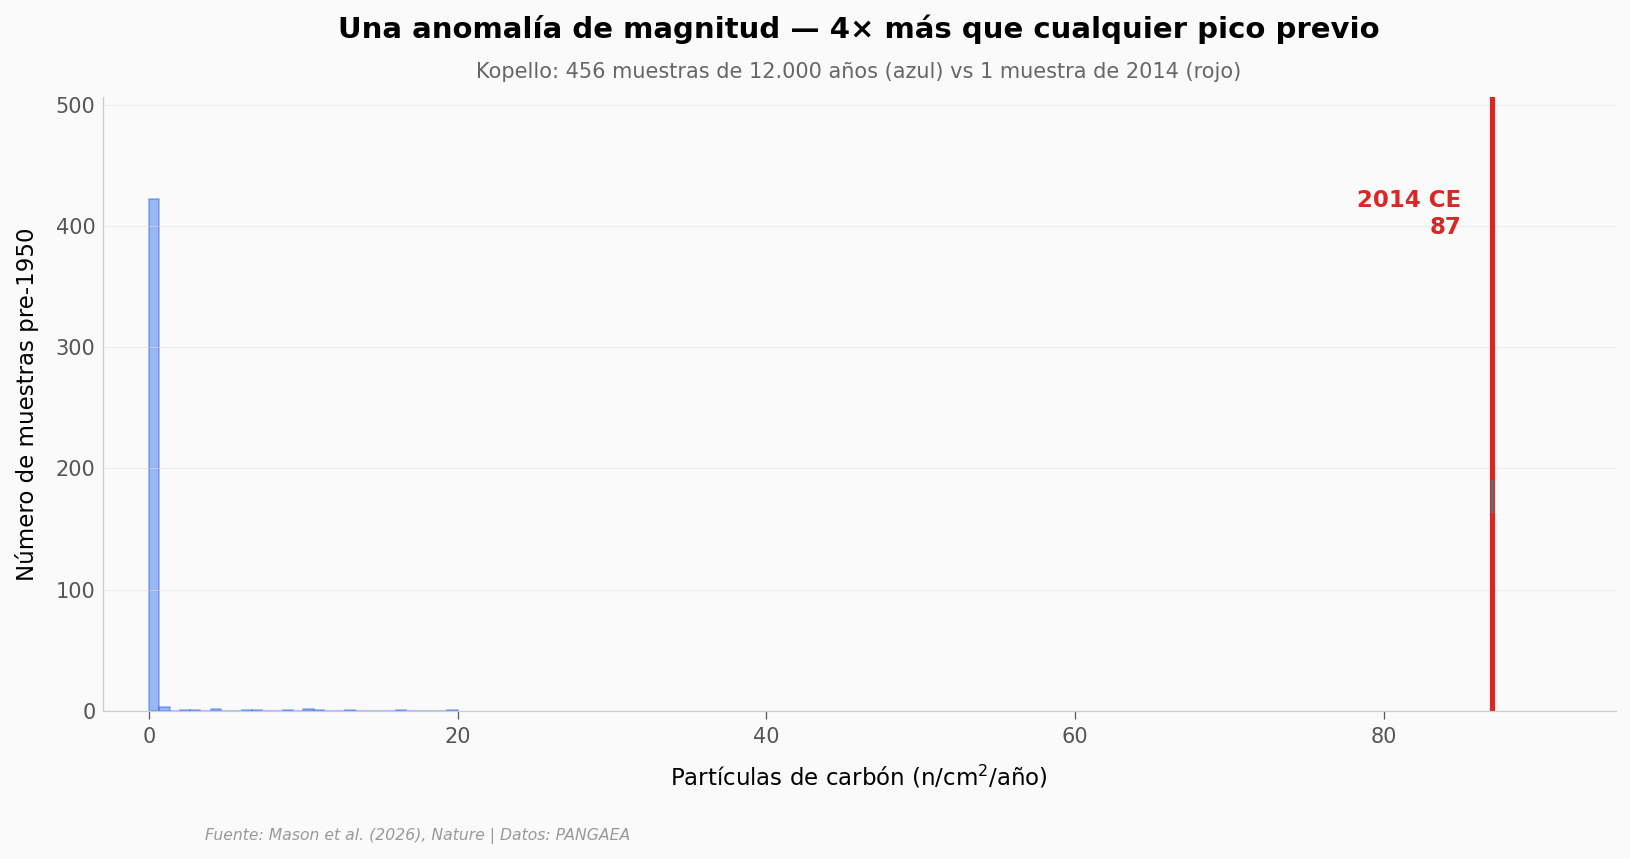

Pico 2014:        87 part/cm²/año
Máximo en 12 ka:  nan  (nan× más)
Media en 12 ka:   nan  (nan× más)


In [5]:
# Histograma de anomalía: la distribución pre-1950 de Kopello + el pico de 2014
fig, ax = plt.subplots(figsize=(11, 5.5))

vals_pre1950 = k[k['age_ka_bp'] >= 0]['charcoal_acc_rate_n_per_cm2_yr'].values

n_bins, bins, patches = ax.hist(vals_pre1950, bins=30, color=COLOR_KOPELLO,
                                alpha=0.45, edgecolor=COLOR_KOPELLO, linewidth=0.8)
y_max = n_bins.max() * 1.20
ax.set_ylim(0, y_max)

mean_pre = vals_pre1950.mean()
median_pre = np.median(vals_pre1950)
max_pre = vals_pre1950.max()
peak_2014 = 87.0

ax.axvline(x=mean_pre, color=COLOR_KOPELLO, linewidth=1.5, linestyle='-', alpha=0.9)
ax.text(mean_pre + 2, y_max * 0.92, f'Media 12.000 años\n{mean_pre:.2f}'.replace('.', ','),
        fontsize=9, color=COLOR_KOPELLO, fontweight='bold', va='top')

ax.axvline(x=max_pre, color=COLOR_REF, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(max_pre + 2, y_max * 0.62, f'Máximo previo\n{max_pre:.0f}',
        fontsize=9, color='#555555', fontweight='bold', va='top')

ax.axvline(x=peak_2014, color=COLOR_MAHOMA, linewidth=2.5)
ax.text(peak_2014 - 2, y_max * 0.85, f'2014 CE\n{peak_2014:.0f}',
        fontsize=11, color=COLOR_MAHOMA, fontweight='bold',
        va='top', ha='right')

# Barra horizontal entre max_pre y 2014 (líneas manuales — annotate con arrowstyle
# falla en líneas perfectamente horizontales)
y_arrow = y_max * 0.35
tick_h = y_max * 0.025
ax.plot([max_pre, peak_2014], [y_arrow, y_arrow], color='#666666', lw=1.5, zorder=4)
ax.plot([max_pre, max_pre], [y_arrow - tick_h, y_arrow + tick_h],
        color='#666666', lw=1.5, zorder=4)
ax.plot([peak_2014, peak_2014], [y_arrow - tick_h, y_arrow + tick_h],
        color='#666666', lw=1.5, zorder=4)
ratio = peak_2014 / max_pre
ax.text((max_pre + peak_2014) / 2, y_max * 0.40,
        f'{ratio:.2f}×'.replace('.', ','),
        fontsize=11, fontweight='bold', color='#333333', ha='center')

ax.set_xlabel('Partículas de carbón (n/cm$^2$/año)', fontsize=11)
ax.set_ylabel('Número de muestras pre-1950', fontsize=11)
ax.set_title('Una anomalía de magnitud — 4× más que cualquier pico previo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Kopello: 456 muestras de 12.000 años (azul) vs 1 muestra de 2014 (rojo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(-3, 95)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/anomalia_2014.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pico 2014:        {peak_2014:.0f} part/cm²/año')
print(f'Máximo en 12 ka:  {max_pre:.0f}  ({peak_2014/max_pre:.2f}× más)')
print(f'Media en 12 ka:   {mean_pre:.2f}  ({peak_2014/mean_pre:.0f}× más)')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El pico de 2014 en Kopello (4.017 m) es la mayor magnitud de fuego local en 12.000 años | ✅ con matiz | Pico de 87 part/cm²/año vs máximo previo de 20 (ratio 4,35×) y media de 0,39 (ratio 223×). El 86% de las 456 muestras pre-1950 tienen carbón >0 — eso es transporte de fuego regional lejano, no fuego local. Lo sin precedentes es la **magnitud**, no la presencia |
| En Mahoma (2.990 m) el fuego aumenta abruptamente hace ~2.000 años | ✅ | Media pre-2 ka: 0,31 (n=247). Media post-2 ka: 1,73 (n=81). Cambio de 5,5×. Mediana sube de 0,22 a 1,46. Datos no normales (Shapiro p<0,001); Mann-Whitney p<0,001, Cohen's d=2,2 (efecto muy grande) |
| Después del cambio, los pastos (Poaceae) reemplazan parte del bosque | ✅ | Poaceae: 6,8% → 17,8% (+11 puntos porcentuales, d=1,6; n=44 vs n=19). Celtis africana cae 7,5 pp (d=−1,4). Podocarpus sube 8,6 pp (d=1,6). Tres tamaños de efecto muy grandes — patrón consistente con apertura del dosel |
| El cambio coincide con evidencia regional de actividad humana | ⚠️ correlación | El dataset no contiene un proxy independiente de actividad humana — la coincidencia temporal (~2 ka) es la única señal en estos datos. El paper enmarca esto como *highlight the role of humans* (resaltar el papel). Diseño observacional: coincide, no demuestra causalidad |

> **Limitaciones:** los registros de carbón reflejan fuego local pero no distinguen tipo de combustible ni intensidad por evento. La frontera Kopello/Mahoma de 2 ka se eligió por inspección visual del cambio en Mahoma — un análisis formal de quiebres usaría modelos de cambio-punto (por ejemplo, *changepoint*). El paper combina estos indicadores (carbón y polen) con evidencia arqueológica externa (citada como ref. 4) que no está en estos archivos.

## Ahora tú

Tres preguntas para experimentar:

1. **¿Cuánto cambia el `5,5×` de Mahoma si mueves el quiebre?** El paper escoge 2 ka pero el cambio no fue instantáneo. Prueba modificar `SHIFT_KA_MAHOMA` arriba (a 1,5 o 2,5) y vuelve a correr la celda 7. ¿La historia sigue igual? *Pista:* el fold change cambia, el patrón cualitativo no.

2. **¿Qué pasa si comparas Kopello pre-1950 solo con los últimos 2.000 años?** Filtra `k[(k['age_ka_bp'] >= 0) & (k['age_ka_bp'] < 2)]` y recalcula el máximo. *Pista:* el ratio vs 2014 baja un poco, pero sigue siendo grande.

3. **¿Las tres familias de polen se mueven al mismo tiempo?** Grafica los tres porcentajes en función de `age_ka_bp`. ¿Poaceae sube antes o después de que Celtis caiga?

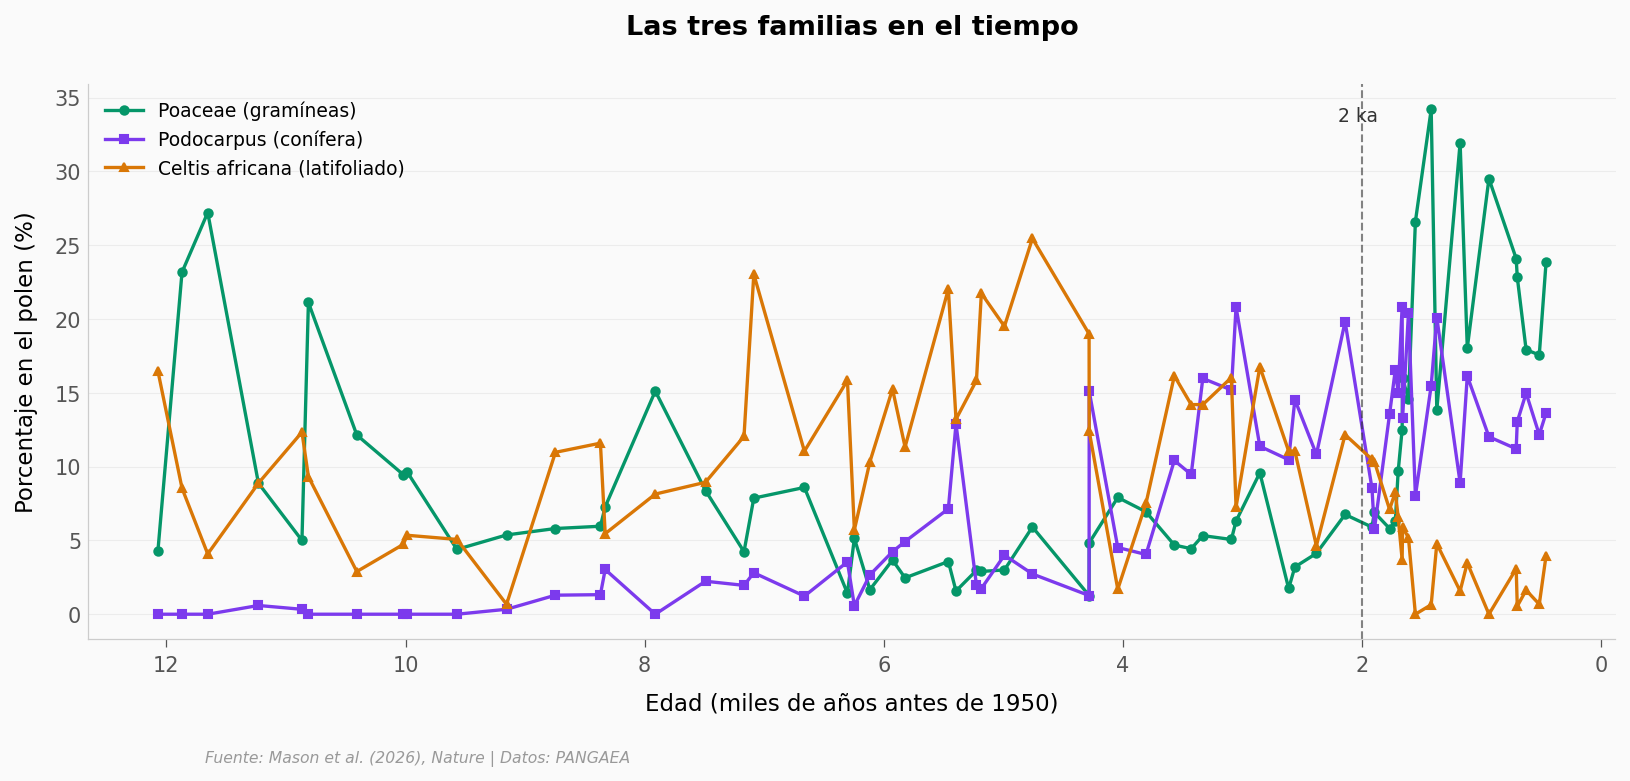

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿Las tres familias de polen se mueven al mismo tiempo?
fig, ax = plt.subplots(figsize=(11, 5))

p_sorted = p.sort_values('age_ka_bp')
ax.plot(p_sorted['age_ka_bp'], p_sorted['poaceae_pct'],
        color=COLOR_POACEAE, linewidth=1.6, marker='o', markersize=4,
        label='Poaceae (gramíneas)')
ax.plot(p_sorted['age_ka_bp'], p_sorted['podocarpus_pct'],
        color=COLOR_PODOCARPUS, linewidth=1.6, marker='s', markersize=4,
        label='Podocarpus (conífera)')
ax.plot(p_sorted['age_ka_bp'], p_sorted['celtis_africana_pct'],
        color=COLOR_CELTIS, linewidth=1.6, marker='^', markersize=4,
        label='Celtis africana (latifoliado)')

ax.axvline(x=SHIFT_KA_MAHOMA, color='#333333', linewidth=1, linestyle='--', alpha=0.6)
ax.text(SHIFT_KA_MAHOMA + 0.2, ax.get_ylim()[1] * 0.93, f'{int(SHIFT_KA_MAHOMA)} ka',
        fontsize=9, color='#333333')

ax.invert_xaxis()
ax.set_xlabel('Edad (miles de años antes de 1950)', fontsize=11)
ax.set_ylabel('Porcentaje en el polen (%)', fontsize=11)
ax.set_title('Las tres familias en el tiempo', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/tres_familias.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Créditos y fuentes

**Notebook reproducible** del canal *Ciencia a Mordiscos*. Código y datos en el [repositorio del Lab](https://github.com/Ciencia-a-Mordiscos/lab).

- **DOI del paper:** [10.1038/s41586-026-10511-w](https://doi.org/10.1038/s41586-026-10511-w)
- **Datos:** PANGAEA (acceso libre, CC-BY)
- **Licencia del notebook:** CC-BY 4.0

## Fuentes

**Paper**: [Twenty-first century emergence of alpine fire in Central African mountains](https://doi.org/10.1038/s41586-026-10511-w)  
*Nature, 2026-05-13*

**Datasets canónicos** (PANGAEA, acceso libre):
- [Lacustrine sedimentary charcoal records of the Rwenzori Mountains, Central Africa: Lake Kopello](https://doi.pangaea.de/10.1594/PANGAEA.987871)
- [Lacustrine sedimentary charcoal records of the Rwenzori Mountains, Central Africa: Lake Mahoma](https://doi.pangaea.de/10.1594/PANGAEA.987874)
- [Lacustrine sedimentary pollen records of the Rwenzori Mountains, Central Africa: Lake Mahoma](https://doi.pangaea.de/10.1594/PANGAEA.987876)

*18 afirmaciones del notebook verificadas contra estas fuentes*